In [1]:
!pip3 install tensorflow tensorflow-hub numpy opencv-python pandas matplotlib seaborn scikit-learn kagglehub kaggle

     |████████████████████████████████| 252.5 MB 98 kB/s s eta 0:00:01
     |████████████████████████████████| 5.4 MB 83.5 MB/s eta 0:00:01
     |████████████████████████████████| 37.3 MB 3.5 MB/s eta 0:00:011
     |████████████████████████████████| 11.3 MB 48 kB/s eta 0:00:01
     |████████████████████████████████| 8.0 MB 62.9 MB/s eta 0:00:01
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
     |████████████████████████████████| 11.1 MB 55.0 MB/s eta 0:00:01
     |████████████████████████████████| 67 kB 4.1 MB/s s eta 0:00:01
     |████████████████████████████████| 1.3 MB 141.6 MB/s eta 0:00:01
     |████████████████████████████████| 417 kB 2.6 MB/s eta 0:00:011
     |████████████████████████████████| 11.3 MB 12 kB/s eta 0:00:011
     |████████████████████████████████| 25.8 MB 16 kB/s eta 0:00:013    |██████████▌                     | 8.5 MB 86 kB/s eta 0:03:21
     |████████████████████████████████| 3.5 MB 1.0 MB/s eta 0:00:01
     |████████████████████████████████| 71 kB 1.

In [7]:
import os
import tensorflow as tf
import tensorflow_hub as hub
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from glob import glob
from tqdm import tqdm

# Funciones para exploración de los datasets

## Visualizar múltiples imagenes

In [8]:
def plot_images(images, titles=None, figsize=(15, 10), rows=3, cols=4):
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        if i >= rows*cols:
            break
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis('off')
        if titles is not None:
            plt.title(titles[i])
    plt.tight_layout()
    plt.show()

## Explorar estructura del dataset

In [16]:
# Función para explorar estructura del dataset
def explore_dataset_structure(dataset_path):
    print(f"Explorando estructura del dataset: {os.path.basename(dataset_path)}")
    
    # Estructura general
    categories = os.listdir(dataset_path)
    categories = [c for c in categories if os.path.isdir(os.path.join(dataset_path, c))]
    print(f"Total de categorías/carpetas: {len(categories)}")
    
    # Muestra las primeras 10 categorías
    print(f"Primeras 10 categorías: {categories[:10]}")
    
    # Analiza la distribución de imágenes por categoría
    category_counts = {}
    total_images = 0
    image_extensions = ['.jpg']
    
    for category in categories:
        category_path = os.path.join(dataset_path, category)
        if os.path.isdir(category_path):
            # Cuenta archivos de imagen en esta categoría
            files = os.listdir(category_path)
            image_files = [f for f in files if os.path.splitext(f.lower())[1] in image_extensions]
            category_counts[category] = len(image_files)
            total_images += len(image_files)
    
    print(f"Total de imágenes: {total_images}")
    
    # Estadísticas de imágenes por categoría
    counts = np.array(list(category_counts.values()))
    print(f"Promedio de imágenes por categoría: {np.mean(counts):.2f}")
    print(f"Mediana de imágenes por categoría: {np.median(counts):.2f}")
    print(f"Mínimo: {np.min(counts)}, Máximo: {np.max(counts)}")
    
    # Visualizamos la distribución
    plt.figure(figsize=(10, 6))
    plt.hist(counts, bins=20)
    plt.title('Distribución de imágenes por categoría')
    plt.xlabel('Número de imágenes')
    plt.ylabel('Número de categorías')
    plt.show()
    
    # Top 10 categorías con más imágenes
    top_categories = sorted(category_counts.items(), key=lambda x: x[1], reverse=True)[:10]
    plt.figure(figsize=(12, 6))
    sns.barplot(x=[c[0] for c in top_categories], y=[c[1] for c in top_categories])
    plt.title('Top 10 categorías por número de imágenes')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    return categories, category_counts

## Explorar características de imágenes

In [10]:
# Función para explorar características de imágenes
def explore_image_characteristics(dataset_path, categories, samples_per_category=2):
    print("\nExplorando características de las imágenes...")
    
    image_shapes = []
    image_sizes = []
    sample_images = []
    sample_titles = []
    
    # Muestrear algunas categorías para análisis
    if len(categories) > 10:
        sample_categories = np.random.choice(categories, 10, replace=False)
    else:
        sample_categories = categories
    
    for category in sample_categories:
        category_path = os.path.join(dataset_path, category)
        if not os.path.isdir(category_path):
            continue
            
        files = os.listdir(category_path)
        image_extensions = ['.jpg', '.jpeg', '.png', '.bmp']
        image_files = [f for f in files if os.path.splitext(f.lower())[1] in image_extensions]
        
        if not image_files:
            continue
            
        # Muestrear algunas imágenes de esta categoría
        if len(image_files) > samples_per_category:
            sampled_files = np.random.choice(image_files, samples_per_category, replace=False)
        else:
            sampled_files = image_files
            
        for img_file in sampled_files:
            img_path = os.path.join(category_path, img_file)
            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                if img is not None:
                    image_shapes.append(img.shape)
                    image_sizes.append(img.size)
                    sample_images.append(img)
                    sample_titles.append(f"{category}\n{img.shape}")
            except Exception as e:
                print(f"Error al procesar {img_path}: {e}")
    
    # Mostrar algunas imágenes de muestra
    if sample_images:
        print(f"Mostrando {len(sample_images)} imágenes de muestra...")
        plot_images(sample_images, sample_titles)
    
    # Análisis de dimensiones
    if image_shapes:
        shapes_counter = Counter([f"{s[0]}x{s[1]}" for s in image_shapes])
        print("\nDimensiones más comunes de imágenes:")
        for shape, count in shapes_counter.most_common(5):
            print(f"{shape}: {count} imágenes")
        
        # Histograma de dimensiones
        heights = [s[0] for s in image_shapes]
        widths = [s[1] for s in image_shapes]
        
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.hist(heights, bins=20)
        plt.title('Distribución de Altura')
        plt.xlabel('Altura (píxeles)')
        plt.ylabel('Frecuencia')
        
        plt.subplot(1, 2, 2)
        plt.hist(widths, bins=20)
        plt.title('Distribución de Ancho')
        plt.xlabel('Ancho (píxeles)')
        plt.ylabel('Frecuencia')
        
        plt.tight_layout()
        plt.show()

## Explorar secuencias en MSLwords1

In [11]:
# Función para explorar secuencias en MSLwords1
def explore_sequence_dataset(dataset_path):
    print(f"\nExplorando características específicas de dataset de secuencias: {os.path.basename(dataset_path)}")
    
    categories = os.listdir(dataset_path)
    categories = [c for c in categories if os.path.isdir(os.path.join(dataset_path, c))]
    
    sequence_lengths = []
    sample_sequences = []
    sample_titles = []
    
    # Muestrear algunas categorías
    if len(categories) > 5:
        sample_categories = np.random.choice(categories, 5, replace=False)
    else:
        sample_categories = categories
    
    for category in sample_categories:
        category_path = os.path.join(dataset_path, category)
        if not os.path.isdir(category_path):
            continue
            
        # En un dataset de secuencias, cada subcarpeta podría representar una secuencia
        sequences = os.listdir(category_path)
        sequences = [s for s in sequences if os.path.isdir(os.path.join(category_path, s))]
        
        if not sequences:
            # Si no hay subcarpetas, puede que las imágenes estén directamente en la carpeta de categoría
            files = os.listdir(category_path)
            image_extensions = ['.jpg', '.jpeg', '.png', '.bmp']
            image_files = [f for f in files if os.path.splitext(f.lower())[1] in image_extensions]
            
            # Ordenar por nombre para mantener la secuencia
            image_files.sort()
            sequence_lengths.append(len(image_files))
            
            # Muestrear algunas imágenes de la secuencia para visualización
            if len(image_files) > 0:
                # Tomar primer, medio y último frame
                indices = [0]
                if len(image_files) > 2:
                    indices.append(len(image_files) // 2)
                if len(image_files) > 1:
                    indices.append(len(image_files) - 1)
                    
                seq_samples = []
                for idx in indices:
                    img_path = os.path.join(category_path, image_files[idx])
                    try:
                        img = cv2.imread(img_path)
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        if img is not None:
                            seq_samples.append(img)
                    except Exception as e:
                        print(f"Error al procesar {img_path}: {e}")
                
                if seq_samples:
                    sample_sequences.extend(seq_samples)
                    sample_titles.extend([f"{category}\nFrame {i+1}/{len(image_files)}" for i in indices])
        else:
            # Si hay subcarpetas, analizar cada secuencia
            for seq in sequences:
                seq_path = os.path.join(category_path, seq)
                files = os.listdir(seq_path)
                image_extensions = ['.jpg', '.jpeg', '.png', '.bmp']
                image_files = [f for f in files if os.path.splitext(f.lower())[1] in image_extensions]
                
                sequence_lengths.append(len(image_files))
    
    # Mostrar estadísticas de longitud de secuencias
    if sequence_lengths:
        print("\nEstadísticas de longitud de secuencias:")
        print(f"Promedio: {np.mean(sequence_lengths):.2f} frames")
        print(f"Mediana: {np.median(sequence_lengths):.2f} frames")
        print(f"Mínimo: {np.min(sequence_lengths)} frames, Máximo: {np.max(sequence_lengths)} frames")
        
        plt.figure(figsize=(10, 6))
        plt.hist(sequence_lengths, bins=20)
        plt.title('Distribución de longitud de secuencias')
        plt.xlabel('Número de frames')
        plt.ylabel('Frecuencia')
        plt.show()
    
    # Mostrar ejemplos de secuencias
    if sample_sequences:
        print(f"\nMostrando {len(sample_sequences)} frames de ejemplo...")
        plot_images(sample_sequences, sample_titles)

## Rutas de los datasets

In [14]:
msl_dataset_path = "/Users/andres/proyecto_final/Real-Time-Spanish-Sign-Language-Recognition/datasets/MSLwords1"
ssl_dataset_path = "/Users/andres/proyecto_final/Real-Time-Spanish-Sign-Language-Recognition/datasets/SSLdictionary"

## Explorar MSLwords1


=== EXPLORANDO DATASET DE SECUENCIAS (MSLwords1) ===
Explorando estructura del dataset: MSLwords1
Total de categorías/carpetas: 218
Primeras 10 categorías: ['135', '132', '104', '103', '168', '157', '150', '159', '166', '192']
Total de imágenes: 0
Promedio de imágenes por categoría: 0.00
Mediana de imágenes por categoría: 0.00
Mínimo: 0, Máximo: 0


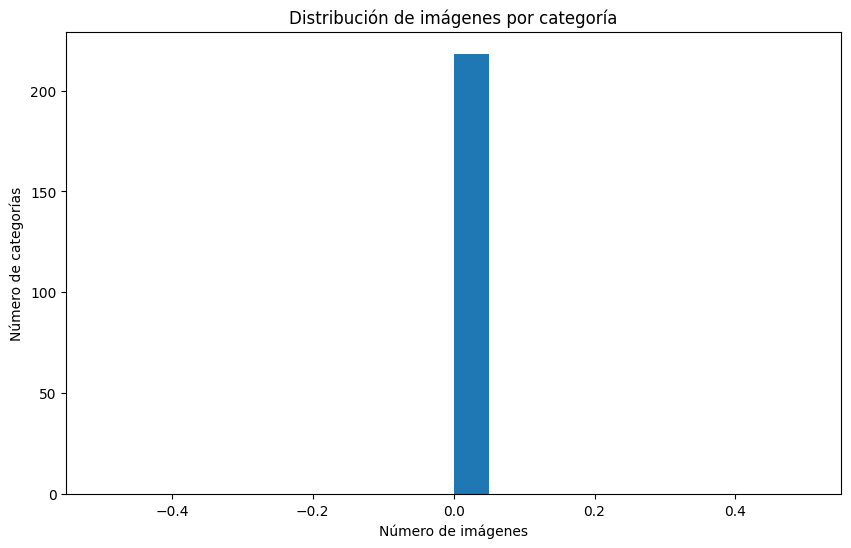

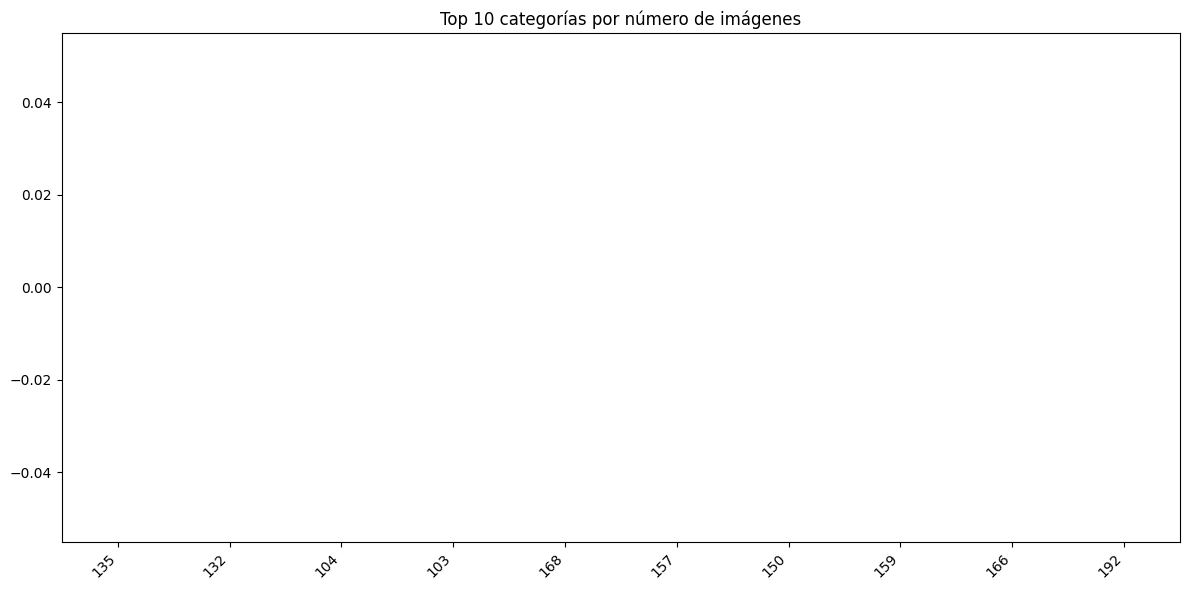

In [17]:
# Explorar MSLwords1 (dataset de secuencias)
print("\n=== EXPLORANDO DATASET DE SECUENCIAS (MSLwords1) ===")
msl_categories, msl_counts = explore_dataset_structure(msl_dataset_path)

## Explorar características 

In [18]:
# Explorar características de imágenes en MSLwords1
explore_image_characteristics(msl_dataset_path, msl_categories)


Explorando características de las imágenes...



Explorando características específicas de dataset de secuencias: MSLwords1

Estadísticas de longitud de secuencias:
Promedio: 11.85 frames
Mediana: 11.00 frames
Mínimo: 9 frames, Máximo: 17 frames


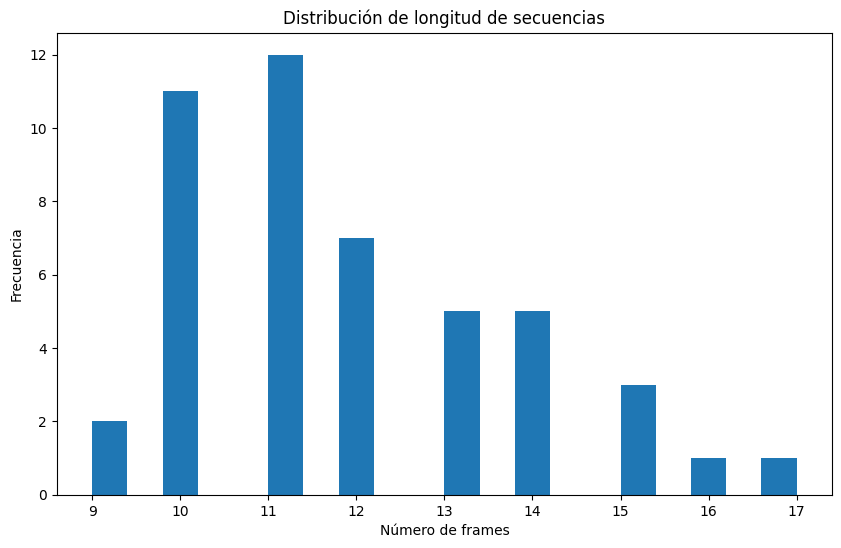

In [19]:
# Explorar secuencias en MSLwords1
explore_sequence_dataset(msl_dataset_path)


=== EXPLORANDO DATASET DE DICCIONARIO (SSLdictionary) ===
Explorando estructura del dataset: SSLdictionary
Total de categorías/carpetas: 19
Primeras 10 categorías: ['R', 'U', 'I', 'N', 'G', 'T', 'S', 'A', 'F', 'O']
Total de imágenes: 1998
Promedio de imágenes por categoría: 105.16
Mediana de imágenes por categoría: 105.00
Mínimo: 90, Máximo: 120


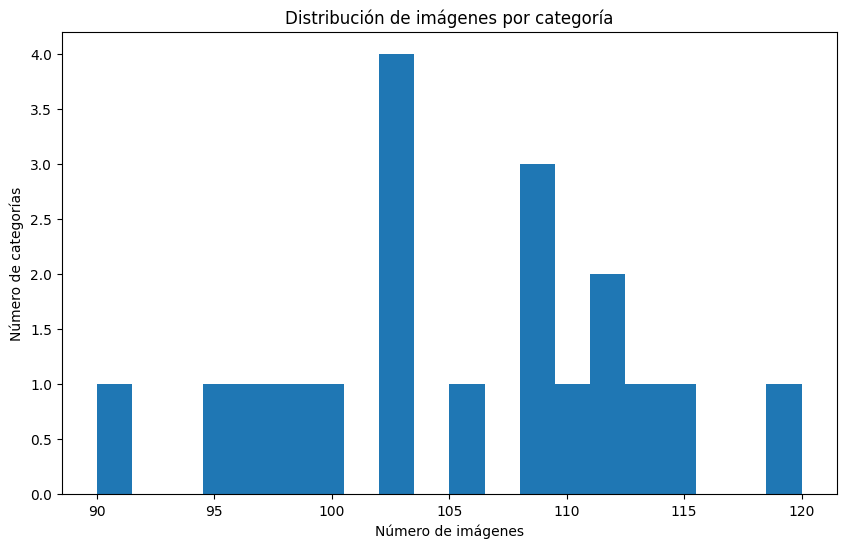

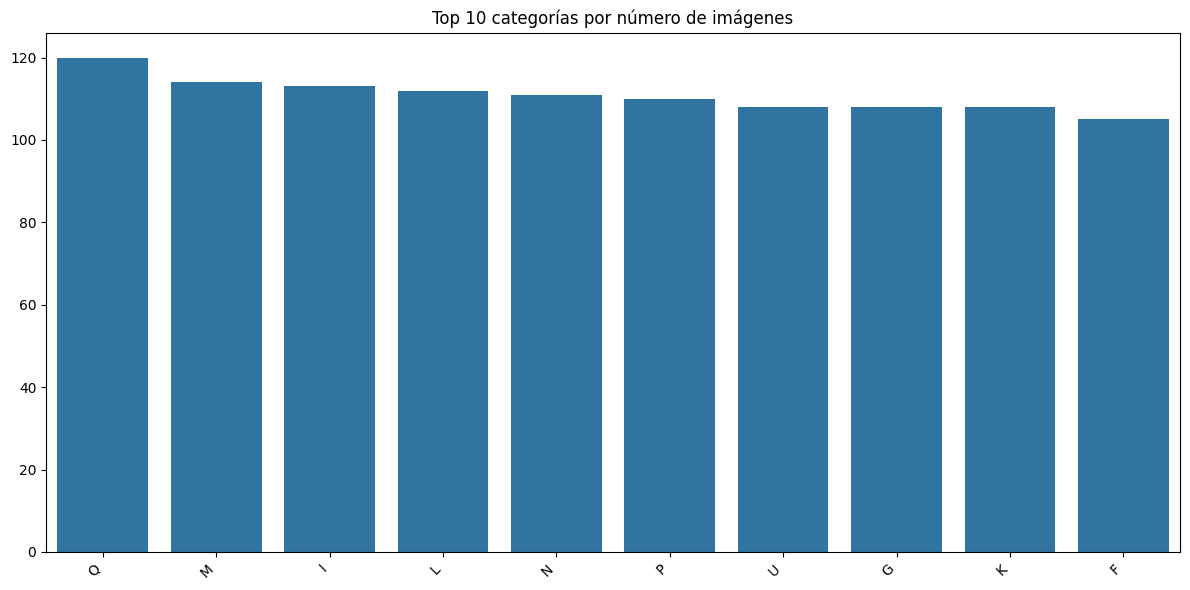

In [20]:
# Explorar SSLdictionary (dataset de diccionario)
print("\n=== EXPLORANDO DATASET DE DICCIONARIO (SSLdictionary) ===")
ssl_categories, ssl_counts = explore_dataset_structure(ssl_dataset_path)


Explorando características de las imágenes...
Mostrando 20 imágenes de muestra...


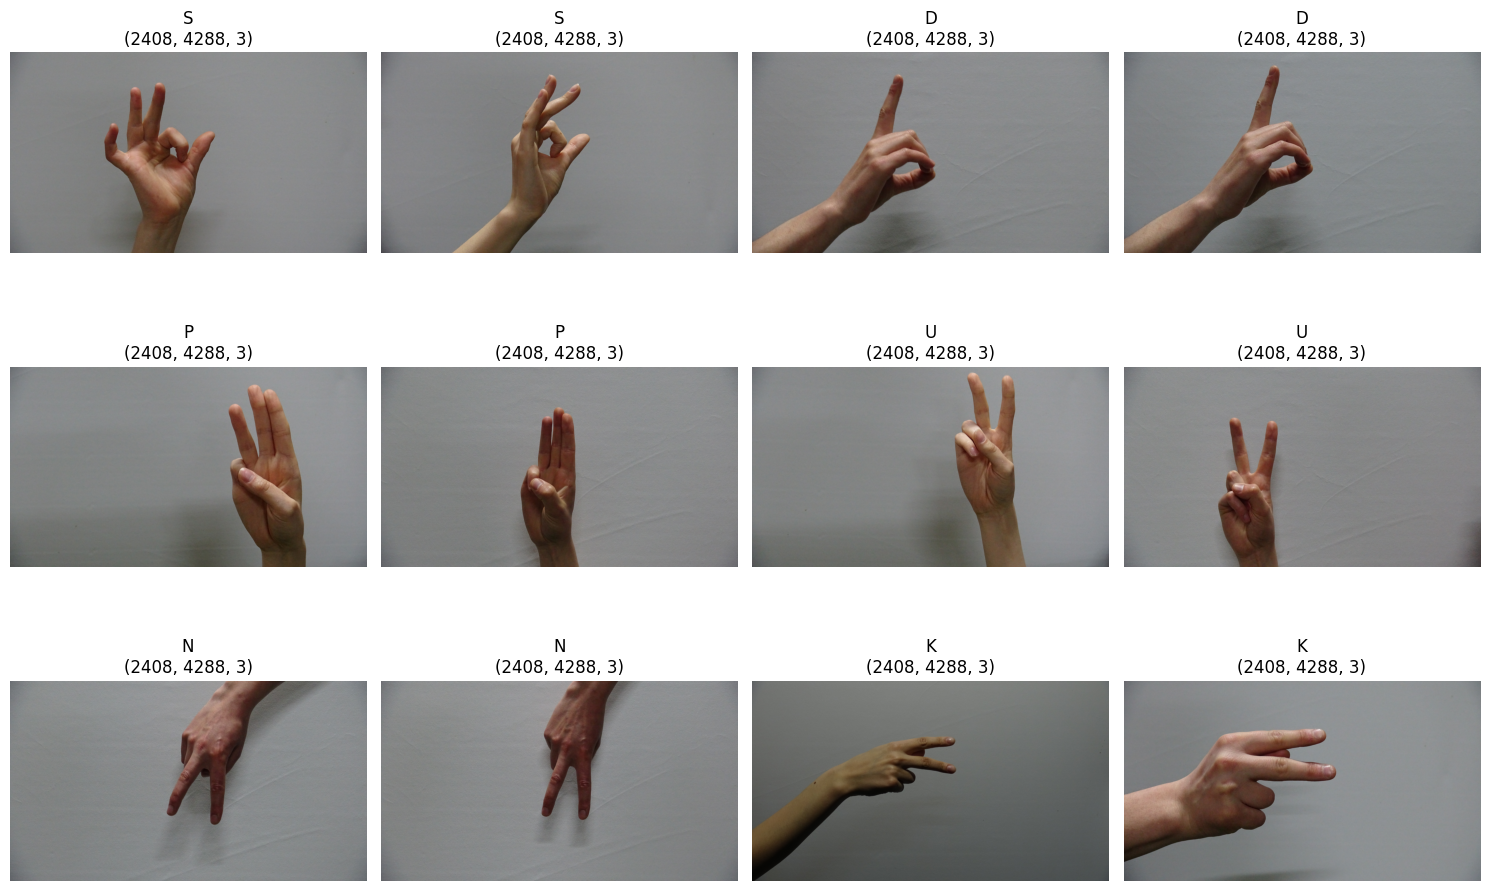


Dimensiones más comunes de imágenes:
2408x4288: 20 imágenes


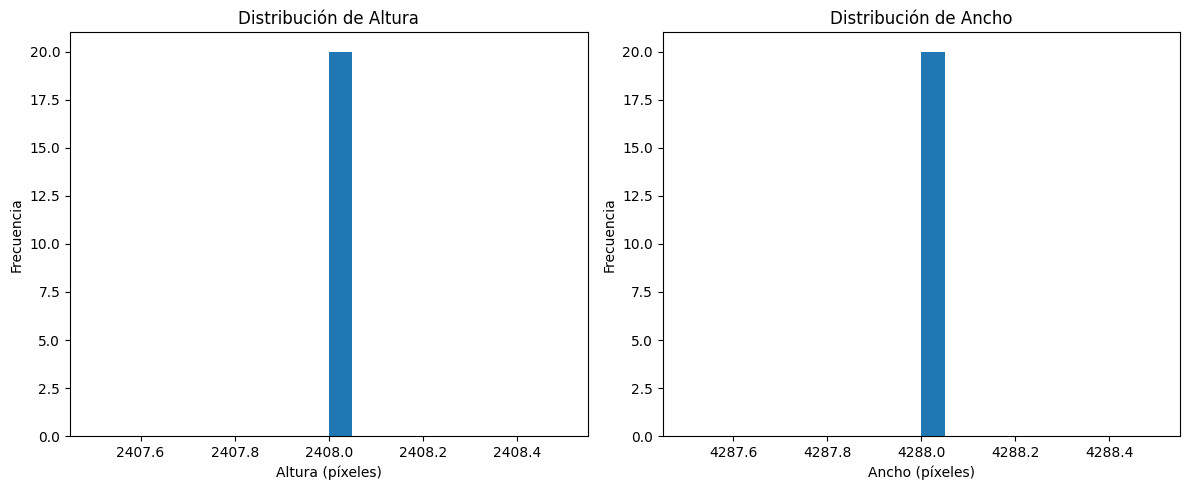

In [21]:
# Explorar características de imágenes en SSLdictionary
explore_image_characteristics(ssl_dataset_path, ssl_categories)